## HR Employee Attrition Analysis
Objective: Analyze 1,470 IBM employees to identify the factors associated with employee attrition.

dataset 1470 employee record IBM 

tools
python ,pandas ,plotly

key questions

1- Does years at the company affect employee attrition?

2- Does the number of years with the same manager affect employee attrition?

3- Does time since the last promotion affect employee attrition?

4-Do satisfaction levels affect employee attrition?


In [1]:
#data manipulation
import pandas as pd
# visualiztion
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [2]:
df=pd.read_csv("HR-Employee-Attrition.csv")

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## gender and attrition

In [5]:
df_by_gender=df.groupby('Gender')['Attrition'].value_counts().reset_index()
df_by_gender

,Gender,Attrition,count
0,Female,No,501
1,Female,Yes,87
2,Male,No,732
3,Male,Yes,150


In [6]:
df_by_gender['pct']=df_by_gender.groupby('Gender')['count'].transform(lambda x: x/x.sum()*100)
df_by_gender[df_by_gender['Attrition']=='Yes'][['Gender','pct']]

,Gender,pct
1,Female,14.795918
3,Male,17.006803


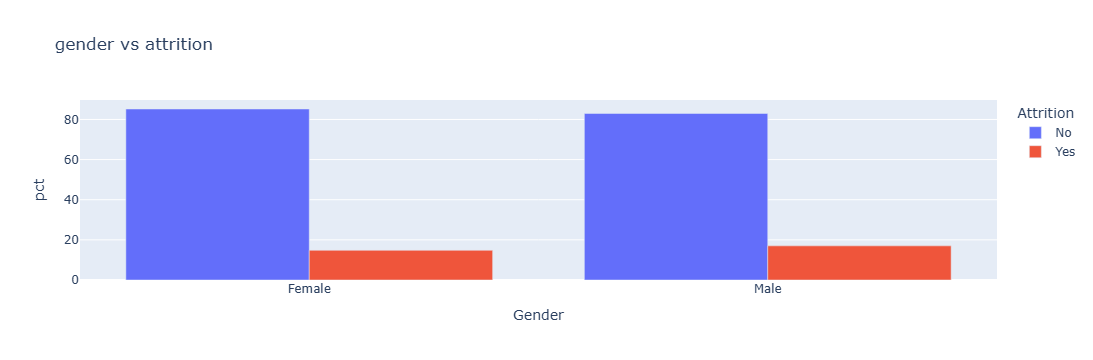

In [7]:
fig=px.bar(df_by_gender,x='Gender',
           y='pct',
           color='Attrition',
           barmode="group",
           title='gender vs attrition')
fig.show()

85% from female and 83% from male are not attrition in the company, so Gender does not appear to have a significant impact on employee attrition.

## Marital Status vs Attrition

In [8]:
df_by_MaritalStatus=df.groupby('MaritalStatus')['Attrition'].value_counts().reset_index()
df_by_MaritalStatus

,MaritalStatus,Attrition,count
0,Divorced,No,294
1,Divorced,Yes,33
2,Married,No,589
3,Married,Yes,84
4,Single,No,350
5,Single,Yes,120


In [9]:
df_by_MaritalStatus['pct']=df_by_MaritalStatus.groupby('MaritalStatus')['count'].transform(lambda x:x/x.sum()*100)
df_by_MaritalStatus

,MaritalStatus,Attrition,count,pct
0,Divorced,No,294,89.908257
1,Divorced,Yes,33,10.091743
2,Married,No,589,87.518574
3,Married,Yes,84,12.481426
4,Single,No,350,74.468085
5,Single,Yes,120,25.531915


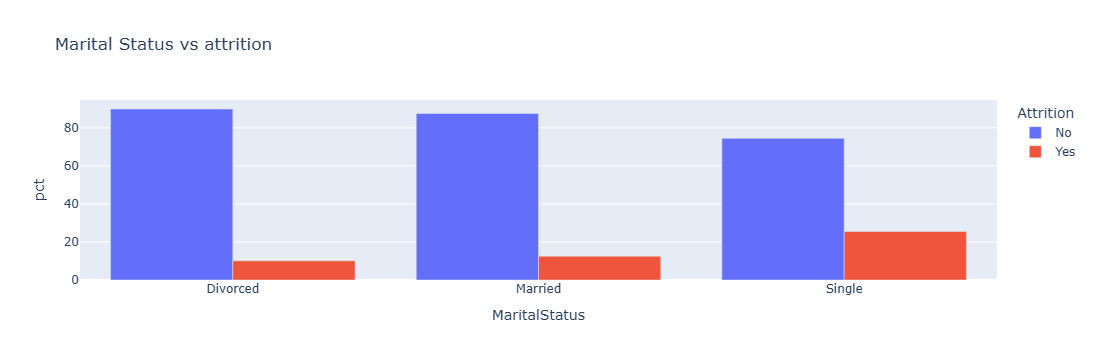

In [10]:
fig=px.bar(df_by_MaritalStatus,x='MaritalStatus',
           y='pct',
           color='Attrition',
           barmode="group",
           title='Marital Status vs attrition')
fig.show()

Single employees have the highest attrition rate (25.5%), while married and divorced employees show similar attrition rates (10–12.4%).

## department vs attrition

In [11]:
df_par_department=df.groupby('Department')['Attrition'].value_counts().reset_index()
df_par_department['pct']=df_par_department.groupby('Department')['count'].transform(lambda x:x/x.sum()*100)
print(df_par_department[df_par_department['Attrition']=='Yes'][['Department','pct']])

               Department        pct
1         Human Resources  19.047619
3  Research & Development  13.839750
5                   Sales  20.627803


Approximately one in five employees in Sales and Human Resources leave the company, compared to around one in ten employees in Research & Development.

## Job Role vs Attrition

In [12]:
df_par_JobRole=df.groupby('JobRole')['Attrition'].value_counts().reset_index()
df_par_JobRole['pct']=df_par_JobRole.groupby('JobRole')['count'].transform(lambda x:x/x.sum()*100)
yes_df_par_JobRole=df_par_JobRole[df_par_JobRole['Attrition']=='Yes'][['JobRole','pct']]

In [13]:
df_par_JobRole

,JobRole,Attrition,count,pct
0,Healthcare Representative,No,122,93.129771
1,Healthcare Representative,Yes,9,6.870229
2,Human Resources,No,40,76.923077
3,Human Resources,Yes,12,23.076923
4,Laboratory Technician,No,197,76.061776
5,Laboratory Technician,Yes,62,23.938224
6,Manager,No,97,95.098039
7,Manager,Yes,5,4.901961
8,Manufacturing Director,No,135,93.103448
9,Manufacturing Director,Yes,10,6.896552


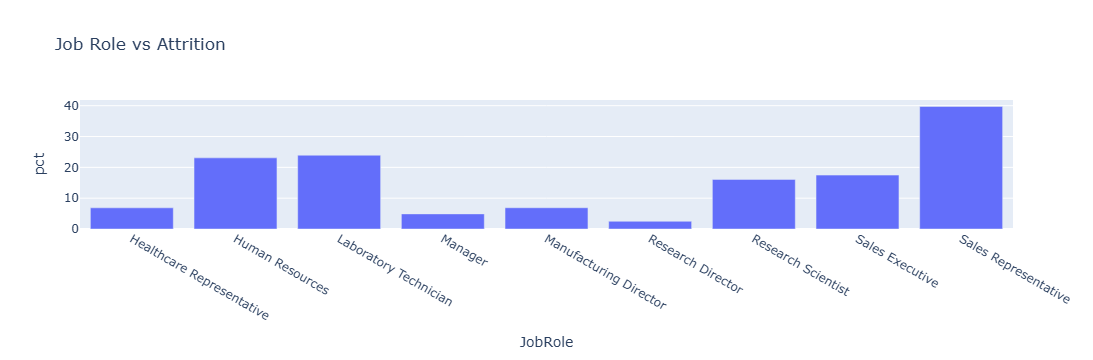

In [14]:
fig=px.bar(yes_df_par_JobRole,x='JobRole',y='pct',title='Job Role vs Attrition')
fig.show()

Sales Representatives have the highest attrition rate (39.75%), followed by Laboratory Technicians (23.94%).


## Monthly Income vs Attrition

In [15]:
df_par_PercentSalaryHike=df.groupby(['JobRole','Attrition'])['PercentSalaryHike'].mean().reset_index()
df_par_PercentSalaryHike

,JobRole,Attrition,PercentSalaryHike
0,Healthcare Representative,No,15.557377
1,Healthcare Representative,Yes,14.000000
2,Human Resources,No,15.100000
3,Human Resources,Yes,13.833333
4,Laboratory Technician,No,14.928934
5,Laboratory Technician,Yes,15.419355
6,Manager,No,15.216495
7,Manager,Yes,13.600000
8,Manufacturing Director,No,15.711111
9,Manufacturing Director,Yes,14.000000


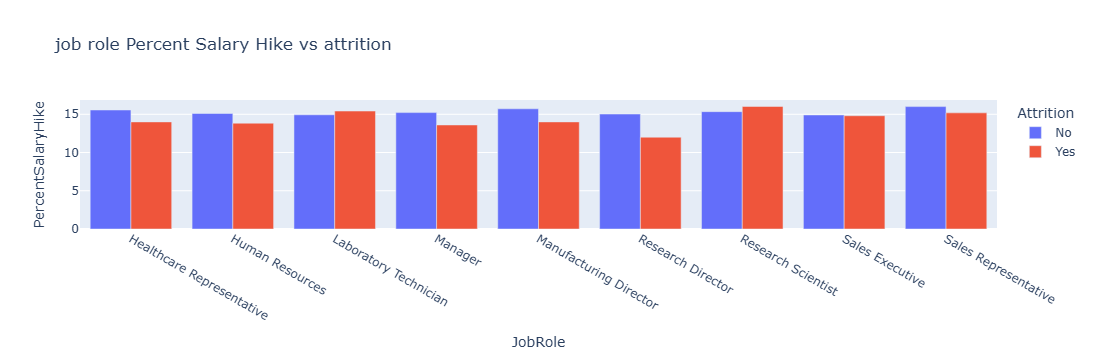

In [16]:
fig=px.bar(df_par_PercentSalaryHike,x='JobRole',
           y='PercentSalaryHike',
           color='Attrition',
           barmode="group",
           title='job role Percent Salary Hike vs attrition')
fig.show()

In [17]:
df_par_MonthlyIncome=df.groupby(['JobRole','Attrition'])['MonthlyIncome'].mean().reset_index().sort_values('MonthlyIncome')
df_par_MonthlyIncome

,JobRole,Attrition,MonthlyIncome
17,Sales Representative,Yes,2364.727273
13,Research Scientist,Yes,2780.468085
16,Sales Representative,No,2798.440000
5,Laboratory Technician,Yes,2919.258065
12,Research Scientist,No,3328.122449
4,Laboratory Technician,No,3337.223350
3,Human Resources,Yes,3715.750000
2,Human Resources,No,4391.750000
14,Sales Executive,No,6804.617100
8,Manufacturing Director,No,7289.925926


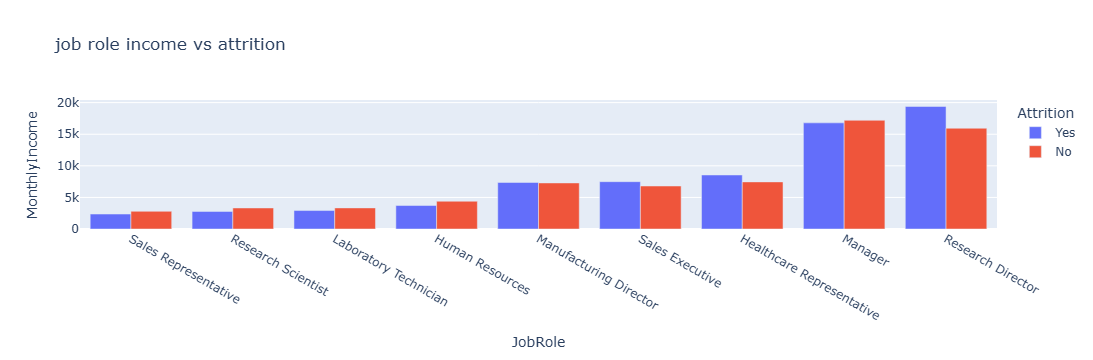

In [18]:
fig=px.bar(df_par_MonthlyIncome,x='JobRole',y='MonthlyIncome',
           barmode='group',color='Attrition',
           title='job role income vs attrition')
fig.show()

Except for managers, employees with higher salaries are not necessarily less likely to leave. Employees who left the company generally had lower average salaries than those who stayed 
— except for the Research Director, Sales Executive, and Healthcare Representative roles. Sales Representatives, who have the highest attrition rate, also have the lowest average salary.

 ##  Hourly rate vs Attrition

In [19]:
print(df[['MonthlyIncome','HourlyRate']].corr())

               MonthlyIncome  HourlyRate
MonthlyIncome       1.000000   -0.015794
HourlyRate         -0.015794    1.000000


In [20]:
df_par_HourlyRate_attrition=df.groupby(['Attrition'])['HourlyRate'].mean().reset_index().sort_values('HourlyRate')

df_par_HourlyRate_attrition

,Attrition,HourlyRate
1,Yes,65.573840
0,No,65.952149


In [21]:
df_par_HourlyRate=df.groupby(['JobRole','Attrition'])['HourlyRate'].mean().reset_index().sort_values('HourlyRate')

df_par_HourlyRate

,JobRole,Attrition,HourlyRate
11,Research Director,Yes,40.000000
3,Human Resources,Yes,62.916667
15,Sales Executive,Yes,63.000000
16,Sales Representative,No,63.700000
10,Research Director,No,64.371795
2,Human Resources,No,64.550000
8,Manufacturing Director,No,64.888889
17,Sales Representative,Yes,65.303030
5,Laboratory Technician,Yes,65.387097
14,Sales Executive,No,65.955390


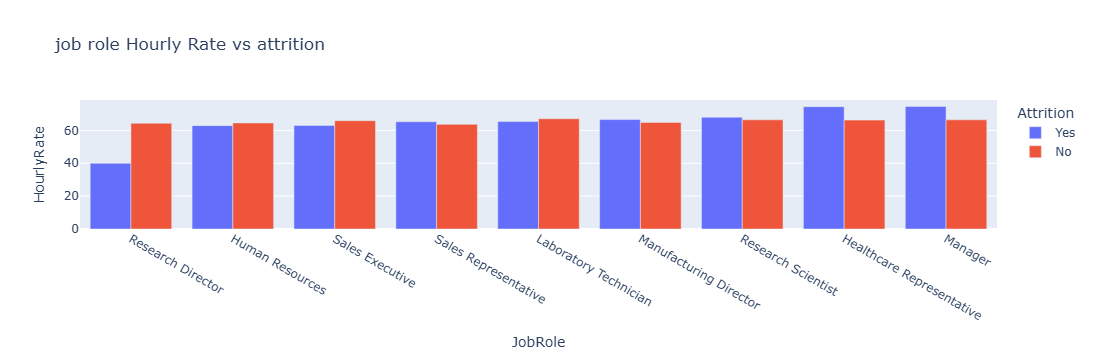

In [22]:
fig=px.bar(df_par_HourlyRate,x='JobRole',
           y='HourlyRate',
           color='Attrition',
           barmode="group",
           title='job role Hourly Rate vs attrition')
fig.show()

Hourly rates are relatively similar across most job roles.

## Year Sinse Last Promotion vs Attrition

In [23]:
df_par_YearsSinceLastPromotion=df.groupby('YearsSinceLastPromotion')['Attrition'].value_counts().reset_index()
df_par_YearsSinceLastPromotion

,YearsSinceLastPromotion,Attrition,count
0,0,No,471
1,0,Yes,110
2,1,No,308
3,1,Yes,49
4,2,No,132
5,2,Yes,27
6,3,No,43
7,3,Yes,9
8,4,No,56
9,4,Yes,5


In [24]:
df.value_counts('YearsSinceLastPromotion')

YearsSinceLastPromotion
0     581
1     357
2     159
7      76
4      61
3      52
5      45
6      32
11     24
8      18
9      17
15     13
13     10
12     10
14      9
10      6
Name: count, dtype: int64

In [25]:
df_par_YearsSinceLastPromotion['pct']=df_par_YearsSinceLastPromotion.groupby('YearsSinceLastPromotion')['count'].transform(lambda x:x/x.sum()*100)
yes_df_par_YearsSinceLastPromotion=df_par_YearsSinceLastPromotion[df_par_YearsSinceLastPromotion['Attrition']=='Yes'][['YearsSinceLastPromotion','pct']]
yes_df_par_YearsSinceLastPromotion

,YearsSinceLastPromotion,pct
1,0,18.932874
3,1,13.725490
5,2,16.981132
7,3,17.307692
9,4,8.196721
11,5,4.444444
13,6,18.750000
15,7,21.052632
18,9,23.529412
20,10,16.666667


 - Employees who have not received a promotion for more than 10 years represent a small group and may not provide reliable conclusions.
- Employees who received a recent promotion still show a relatively high attrition rate of 18.9%.

## Relationship Satisfaction vs attrition

In [26]:
df_par_RelationshipSatisfaction=df.groupby('RelationshipSatisfaction')['Attrition'].value_counts().reset_index()
df_par_RelationshipSatisfaction['pct']=df_par_RelationshipSatisfaction.groupby('RelationshipSatisfaction')['count'].transform(lambda x:x/x.sum()*100)
yes_df_par_RelationshipSatisfaction=df_par_RelationshipSatisfaction[df_par_RelationshipSatisfaction['Attrition']=='Yes'][['RelationshipSatisfaction','pct']]

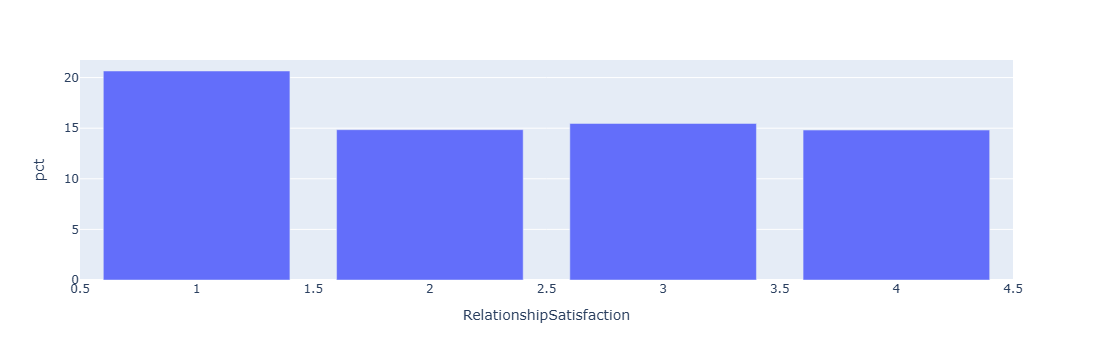

In [27]:
fig=px.bar(yes_df_par_RelationshipSatisfaction,x='RelationshipSatisfaction',y='pct')
fig.show()

Employees with the lowest relationship satisfaction level show an attrition rate of approximately 20%

## Environment Satisfaction vs attrition

In [28]:
df_par_EnvironmentSatisfaction=df.groupby('EnvironmentSatisfaction')['Attrition'].value_counts().reset_index()
df_par_EnvironmentSatisfaction['pct']=df_par_EnvironmentSatisfaction.groupby('EnvironmentSatisfaction')['count'].transform(lambda x:x/x.sum()*100)
yes_df_par_EnvironmentSatisfaction=df_par_EnvironmentSatisfaction[df_par_EnvironmentSatisfaction['Attrition']=='Yes'][['EnvironmentSatisfaction','pct']]

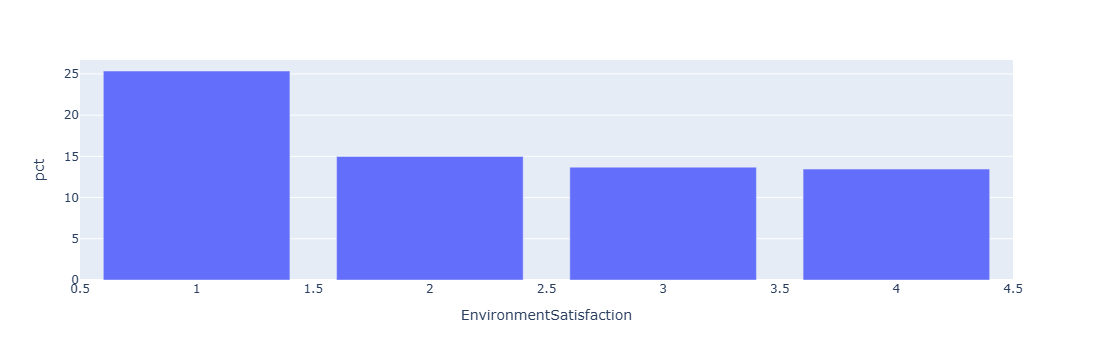

In [29]:
fig=px.bar(yes_df_par_EnvironmentSatisfaction,x='EnvironmentSatisfaction',y='pct')
fig.show()

Employees with the lowest environment satisfaction score show a 25% attrition rate, compared to 15% in other cases. Poor work environment satisfaction is associated with a higher attrition rate.

## Job Satisfaction vs attrition

In [30]:
df_par_JobSatisfaction=df.groupby('JobSatisfaction')['Attrition'].value_counts().reset_index()
df_par_JobSatisfaction['pct']=df_par_JobSatisfaction.groupby('JobSatisfaction')['count'].transform(lambda x:x/x.sum()*100)
yes_df_par_JobSatisfaction=df_par_JobSatisfaction[df_par_JobSatisfaction['Attrition']=='Yes'][['JobSatisfaction','pct']]

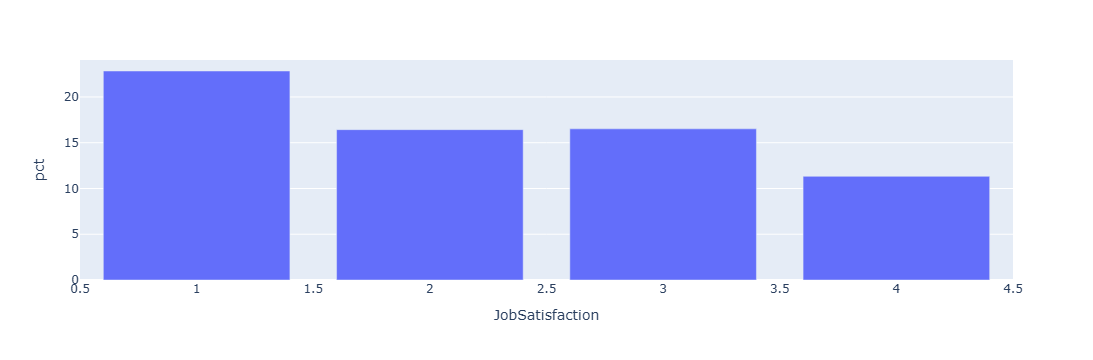

In [31]:
fig=px.bar(yes_df_par_JobSatisfaction,x='JobSatisfaction',y='pct')
fig.show()

Employees with the lowest job satisfaction level are significantly more likely to leave the company.

## BusinessTravel	vs attrition

In [32]:
df_par_BusinessTravel=df.groupby('BusinessTravel')['Attrition'].value_counts().reset_index()
df_par_BusinessTravel['pct']=df_par_BusinessTravel.groupby('BusinessTravel')['count'].transform(lambda x:x/x.sum()*100)
yes_df_par_BusinessTravel=df_par_BusinessTravel[df_par_BusinessTravel['Attrition']=='Yes'][['BusinessTravel','pct']]


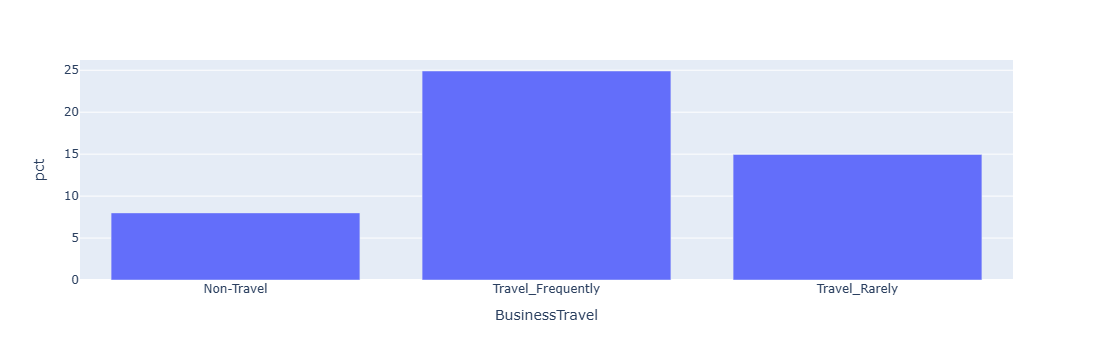

In [33]:
fig=px.bar(yes_df_par_BusinessTravel,x='BusinessTravel',y='pct')
fig.show()

Employees who travel frequently have the highest attrition rate among the travel categories.

## High Risk Profile

In [34]:
high_risk = df[
   ( ((df['RelationshipSatisfaction'] == 1) & (df['EnvironmentSatisfaction'] == 1)) |
    (df['EnvironmentSatisfaction'] == 1)&(df['JobSatisfaction'] == 1) |
    ((df['JobSatisfaction'] == 1)|(df['RelationshipSatisfaction'] == 1))) &
    (df['BusinessTravel'].isin(['Travel_Frequently']))
]
high_risk

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
26,32,Yes,Travel_Frequently,1125,Research & Development,16,1,Life Sciences,1,33,...,2,80,0,10,5,3,10,2,6,7
39,33,No,Travel_Frequently,1141,Sales,1,3,Life Sciences,1,52,...,1,80,2,10,3,3,5,3,1,3
56,35,No,Travel_Frequently,853,Sales,18,5,Life Sciences,1,74,...,4,80,1,9,3,2,9,8,1,8
68,35,No,Travel_Frequently,664,Research & Development,1,3,Medical,1,88,...,4,80,1,5,2,2,3,2,1,2
93,46,No,Travel_Frequently,638,Research & Development,1,3,Medical,1,124,...,3,80,1,21,5,2,10,9,9,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,32,Yes,Travel_Frequently,238,Research & Development,5,2,Life Sciences,1,1939,...,1,80,0,8,2,3,4,1,0,3
1379,27,Yes,Travel_Frequently,1337,Human Resources,22,3,Human Resources,1,1944,...,1,80,0,1,2,3,1,0,0,0
1389,31,No,Travel_Frequently,1125,Research & Development,1,3,Life Sciences,1,1956,...,2,80,0,10,6,3,10,8,8,7
1409,40,No,Travel_Frequently,692,Research & Development,11,3,Technical Degree,1,1985,...,1,80,1,10,2,4,10,9,9,4


In [35]:
high_risk_Attrition=high_risk.value_counts('Attrition').reset_index()
high_risk_Attrition

,Attrition,count
0,No,64
1,Yes,30


In [36]:
high_risk_Attrition['pct']=high_risk_Attrition['count'].transform(lambda x:x/x.sum()*100)
high_risk_Attrition

,Attrition,count,pct
0,No,64,68.085106
1,Yes,30,31.914894


Employees who travel frequently and report low satisfaction levels are nearly twice as likely to leave the company compared to the average employee.

##  Attrition Funnel

All Employees

In [37]:
df_attrition=df.value_counts('Attrition').reset_index()
df_attrition['pct']=df_attrition['count'].transform(lambda x:x/x.sum()*100 )
df_attrition[df_attrition['Attrition']=='Yes']

,Attrition,count,pct
1,Yes,237,16.122449


Employee Who Travel Frequently

In [38]:
df_travel_frequently=df.groupby('BusinessTravel')['Attrition'].value_counts().reset_index()
travel = df[df['BusinessTravel']=='Travel_Frequently']

travel['Attrition'].eq('Yes').mean()*100


np.float64(24.90974729241877)

Employee Who Travel Frequently and Have Very Low Job Satisfaction

In [39]:

travel = df[(df['BusinessTravel']=='Travel_Frequently') & (df['JobSatisfaction'].isin([1,2]))]

travel['Attrition'].eq('Yes').mean()*100

np.float64(28.000000000000004)

In [40]:

travel = df[(df['BusinessTravel']=='Travel_Frequently') & (df['JobSatisfaction'].isin([1,2])) & (df['YearsSinceLastPromotion']<1)]

travel['Attrition'].eq('Yes').mean()*100

np.float64(40.0)

Employees who travel frequently and report the lowest level of job satisfaction show a 40% attrition rate, compared to 16.1% across the company, making them approximately 2.5 times more likely to leave.


# Summary

The overall attrition rate is 16%, with a slightly higher rate 
among males (17%) compared to females (15%), indicating that 
gender is not a significant factor.

Single employees show the highest attrition rate (25.5%), 
compared to 12% for married and 10% for divorced employees, 
suggesting that employees with fewer personal responsibilities 
are more likely to leave.

The Sales and HR departments show the highest attrition rates (20% and 19%), while Research & Development has a notably lower rate of 13%.

Among job roles, Sales Representatives have the highest attrition rate at nearly 40%, also showing the lowest average salary — suggesting compensation is a key driver.

Employees who received a promotion within the last year but report low satisfaction show disproportionately high attrition rates.

Low scores in environment satisfaction, job satisfaction, and relationship satisfaction are all associated with higher attrition, confirming that workplace wellbeing is a critical retention factor.

Employees who travel frequently show an attrition rate of 24.9%.When combined with low job satisfaction, this rate rises to 40% — 2.5 times the company average — identifying frequent travelers with low satisfaction as the highest-risk group for attrition.


# Recommendations

1. Increase travel compensation and introduce flexible remote work options for frequently traveling employees to reduce burnout.

2. Review the promotion schedule — employees who received recent promotions but remain unsatisfied may need clearer career growth paths.

3. Review the salary structure for Sales Representatives, as they show the highest attrition rate combined with the lowest average salary.

4. Implement a high-risk employee monitoring program targeting frequent travelers with low satisfaction scores, as this group shows a 40% attrition rate — 2.5x the company average.

